<a href="https://colab.research.google.com/github/youma-code/qqq/blob/main/1.1.0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import time

# ======================
# データ取得
# ======================
ticker = "AAPL"
start_date = "2020-01-01"
end_date = pd.to_datetime("today").strftime("%Y-%m-%d")

def download_data(ticker, start, end):
    for _ in range(5):
        df = yf.download(ticker, start=start, end=end)
        if not df.empty:
            return df
        time.sleep(3)
    return pd.DataFrame()

df = download_data(ticker, start_date, end_date)

# ======================
# 整形
# ======================
if isinstance(df.columns, pd.MultiIndex):
    df = df[['Close', 'High', 'Low', 'Volume']].droplevel(1, axis=1)
else:
    df = df[['Close', 'High', 'Low', 'Volume']].copy()

df.columns = ['Close', 'High', 'Low', 'Volume']
df.dropna(inplace=True)

# ======================
# 特徴量作成（強化版）
# ======================

# --- SMA系 ---
df["SMA_5"] = df["Close"].rolling(5).mean()
df["SMA_25"] = df["Close"].rolling(25).mean()
df["SMA_DIFF"] = df["SMA_5"] - df["SMA_25"]
df["SMA_RATIO"] = df["SMA_5"] / (df["SMA_25"] + 1e-9)

# --- Target ---
future_max = df["Close"].shift(-1).rolling(3).max()
df["Target"] = ((future_max / df["Close"] - 1) > 0.0075).astype(int)

# --- RSI ---
delta = df["Close"].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = (-delta.clip(upper=0)).rolling(14).mean()
rs = gain / (loss + 1e-9)
df["RSI"] = 100 - (100 / (1 + rs))

# --- MACD ---
ema12 = df["Close"].ewm(span=12).mean()
ema26 = df["Close"].ewm(span=26).mean()
df["MACD"] = ema12 - ema26
df["Signal_Line"] = df["MACD"].ewm(span=9).mean()
df["MACD_Hist"] = df["MACD"] - df["Signal_Line"]

# --- ボラ・リターン ---
df["Daily_Return"] = df["Close"].pct_change()
df["Volatility_Short"] = df["Daily_Return"].rolling(5).std()

# --- ATR ---
tr = pd.concat([
    df["High"] - df["Low"],
    abs(df["High"] - df["Close"].shift()),
    abs(df["Low"] - df["Close"].shift())
], axis=1).max(axis=1)

df["ATR"] = tr.rolling(14).mean()

# ======================
# 🔥追加強化特徴量
# ======================

# モメンタム
df["RET_3"] = df["Close"].pct_change(3)
df["RET_5"] = df["Close"].pct_change(5)
df["RET_10"] = df["Close"].pct_change(10)

# ボラ構造
df["VOL_10"] = df["Daily_Return"].rolling(10).std()
df["VOL_20"] = df["Daily_Return"].rolling(20).std()
df["VOL_RATIO"] = df["VOL_10"] / (df["VOL_20"] + 1e-9)

# レンジ度
df["RANGE_SCORE"] = abs(df["RSI"] - 50)

# モメンタム補助
df["MOMENTUM"] = df["Close"] - df["Close"].shift(5)

# ======================
# cleanup
# ======================
df = df.dropna()

# ======================
# ADX（ここが重要）
# ======================
window = 14

plus_dm = df["High"].diff()
minus_dm = -df["Low"].diff()

plus_dm = plus_dm.clip(lower=0)
minus_dm = minus_dm.clip(lower=0)

tr = pd.concat([
    df["High"] - df["Low"],
    (df["High"] - df["Close"].shift()).abs(),
    (df["Low"] - df["Close"].shift()).abs()
], axis=1).max(axis=1)

atr = tr.rolling(window).mean()

plus_di = 100 * (plus_dm.rolling(window).mean() / (atr + 1e-9))
minus_di = 100 * (minus_dm.rolling(window).mean() / (atr + 1e-9))

dx = (abs(plus_di - minus_di) / (plus_di + minus_di + 1e-9)) * 100

df["ADX"] = dx.rolling(window).mean()

# ======================
# 追加特徴量（ADX後にやる！）
# ======================

df["RET_3"] = df["Close"].pct_change(3)
df["RET_5"] = df["Close"].pct_change(5)
df["RET_10"] = df["Close"].pct_change(10)

df["VOL_10"] = df["Daily_Return"].rolling(10).std()
df["VOL_20"] = df["Daily_Return"].rolling(20).std()
df["VOL_RATIO"] = df["VOL_10"] / (df["VOL_20"] + 1e-9)

df["RANGE_SCORE"] = abs(df["RSI"] - 50)
df["MOMENTUM"] = df["Close"] - df["Close"].shift(5)

# ★ここで初めて作る
df["TREND_STRENGTH"] = df["ADX"] * df["MACD_Hist"]

# --- BB ---
ma = df["Close"].rolling(20).mean()
std = df["Close"].rolling(20).std()

df["Upper_BB"] = ma + 2 * std
df["Lower_BB"] = ma - 2 * std
df["BB_Width"] = (df["Upper_BB"] - df["Lower_BB"]) / (ma + 1e-9)

# --- lag ---
for lag in range(1, 6):
    df[f"Close_Lag_{lag}"] = df["Close"].shift(lag)

# ======================
# 🔥新規追加: レジーム分離と正規化ADX
# ======================
df["ADX_normalized"] = df["ADX"] / 100  # ADXを0-1に正規化
# 初期データ準備ではデフォルトのADX閾値を使用 (Optunaで最適化)
default_adx_regime_threshold = 20
df["trend_regime"] = (df["ADX"] > default_adx_regime_threshold).astype(int)

# ======================
# cleanup
# ======================
df.dropna(inplace=True)

print("完了:", df.shape)


/tmp/ipykernel_58362/2547753321.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed

完了: (1535, 36)


In [2]:
# ======================
# 特徴量リスト（固定）
# ======================

features = [
    'SMA_5', 'SMA_25', 'SMA_DIFF', 'SMA_RATIO',
    'RSI', 'MACD', 'Signal_Line', 'MACD_Hist',
    'ATR',
    'Upper_BB', 'Lower_BB', 'BB_Width',
    'Volatility_Short',
    'ADX',
    'ADX_normalized',  # ←追加: 正規化ADX
    'trend_regime',    # ←追加: トレンドレジーム
    'RET_5',           # ←スコアに使用するモメンタム
    'Volatility_Short' # ←スコアに使用するボラティリティ
]
# ラグ特徴量（セル1で作ったやつに対応）
for lag in range(1, 6):
    features.append(f'Close_Lag_{lag}')

# 存在しない列があったら弾く（安全対策）
features = [f for f in features if f in df.columns]

print("使用特徴量数:", len(features))
print(features[:10])


使用特徴量数: 23
['SMA_5', 'SMA_25', 'SMA_DIFF', 'SMA_RATIO', 'RSI', 'MACD', 'Signal_Line', 'MACD_Hist', 'ATR', 'Upper_BB']


In [3]:
# ======================
# X, y 作成
# ======================

# 念のためチェック
assert 'Target' in df.columns, "Target列が存在しません"

# Xとy
X = df[features].copy()
y = df['Target'].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target分布:")
print(y.value_counts(normalize=True))

X shape: (1535, 23)
y shape: (1535,)
Target分布:
Target
0    0.518567
1    0.481433
Name: proportion, dtype: float64


In [4]:
X = df[features]
y = df['Target']
print(f"X and y defined. Feature matrix shape: {X.shape}")

X and y defined. Feature matrix shape: (1535, 23)


In [5]:
# ======================
# 時系列分割
# ======================

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index].copy()
X_test  = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test  = y.iloc[split_index:].copy()

print("Train期間:", X_train.index.min(), "→", X_train.index.max())
print("Test期間 :", X_test.index.min(), "→", X_test.index.max())

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

Train期間: 2020-03-17 00:00:00 → 2025-02-03 00:00:00
Test期間 : 2025-02-04 00:00:00 → 2026-04-24 00:00:00
Train size: (1228, 23)
Test size : (307, 23)


In [6]:
# ======================
# SMOTE（訓練データのみ）
# ======================

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

Before SMOTE: Target
1    618
0    610
Name: count, dtype: int64
After SMOTE:
Target
0    618
1    618
Name: count, dtype: int64


In [7]:
# ======================
# RandomForest チューニング
# ======================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# モデル定義
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# パラメータ範囲
param_dist_rf = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 20),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt', 'log2', None]
}

# チューニング
random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=30,                # 最初は軽めでOK（後で増やせる）
    scoring='f1',             # 不均衡データ向け
    cv=3,                     # 時系列じゃない簡易CV（後で改善）
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# 学習（SMOTE後データ使う）
random_search_rf.fit(X_train_resampled, y_train_resampled)

# 最適モデル
model_rf_tuned = random_search_rf.best_estimator_

print("Best params:", random_search_rf.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best params: {'max_depth': 7, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 9, 'n_estimators': 313}


In [8]:
# ======================
# XGBoost チューニング
# ======================

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# モデル定義
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

# パラメータ範囲
param_dist_xgb = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 12),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 0.5),
    'reg_alpha': uniform(0, 0.5),
    'reg_lambda': uniform(0.5, 1.5)
}

# チューニング
random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    n_iter=30,          # 最初は軽め
    scoring='f1',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# 学習（SMOTE後データ）
# pandas DataFrame/SeriesをNumPy配列に変換して渡すことでAttributeErrorを回避
random_search_xgb.fit(X_train_resampled.values, y_train_resampled.values)

# 最適モデル
model_xgb_tuned = random_search_xgb.best_estimator_

print("Best params:", random_search_xgb.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best params: {'colsample_bytree': np.float64(0.9530545372757359), 'gamma': np.float64(0.09435355417068969), 'learning_rate': np.float64(0.06577427051843637), 'max_depth': 5, 'n_estimators': 403, 'reg_alpha': np.float64(0.42333057111915295), 'reg_lambda': np.float64(1.7844864378171388), 'subsample': np.float64(0.761803250848876)}


In [9]:
# ======================
# 予測確率の取得
# ======================

# RandomForest
proba_class1_rf = model_rf_tuned.predict_proba(X_test)[:, 1]

# XGBoost
# pandas DataFrameをNumPy配列に変換して渡すことでAttributeErrorを回避
proba_class1_xgb = model_xgb_tuned.predict_proba(X_test.values)[:, 1]

# 確認
print("RF proba shape:", proba_class1_rf.shape)
print("XGB proba shape:", proba_class1_xgb.shape)

RF proba shape: (307,)
XGB proba shape: (307,)


In [10]:
# ======================
# 戦略A・Bの定義
# ======================

# 閾値（あとで調整可能）
threshold = 0.6

# --- 戦略A：AND条件（両モデルが強気） ---
strategy_A = (
    (proba_class1_rf > threshold) &
    (proba_class1_xgb > threshold)
).astype(int)

# --- 戦略B：XGBoost重視 ---
strategy_B = (
    (proba_class1_xgb > threshold)
).astype(int)

# 確認
print("Strategy A trades:", strategy_A.sum())
print("Strategy B trades:", strategy_B.sum())

Strategy A trades: 31
Strategy B trades: 75


In [11]:
import numpy as np
import pandas as pd

def run_backtest(
    df,
    X_test,
    signal_multipliers, # Renamed from signals for clarity, represents position size multiplier
    initial_balance=100000
):

    # --- テスト期間 ---
    df_bt = df.loc[X_test.index].copy()

    # 必須データチェック
    required_cols = ['Close', 'ATR']
    df_bt = df_bt.dropna(subset=required_cols)

    # signal_multipliers align
    signal_multipliers = signal_multipliers.loc[df_bt.index] # Align multipliers

    # --- 初期化 ---
    balance = initial_balance
    equity_curve = []

    position = 0
    entry_price = 0
    entry_atr = 0  # ★重要：ATR固定

    trade_count = 0
    win_count = 0
    trade_pnls = [] # ★追加：個別のトレードP/Lを記録

    # --- 固定リスク管理パラメータ ---
    risk_per_trade = 0.01 # 1%リスク
    atr_tp_multiplier = 2.5 # TPは2.5 * ATR
    atr_sl_multiplier = 1.2 # SLは1.2 * ATR

    # ======================
    # メインループ
    # ======================
    for i in range(len(df_bt) - 1):

        row = df_bt.iloc[i]
        next_row = df_bt.iloc[i + 1]

        current_signal_multiplier = signal_multipliers.iloc[i] # Get current multiplier

        # ======================
        # エントリー
        # ======================
        # Entry if the signal multiplier is greater than 0
        if position == 0 and current_signal_multiplier > 0:

            atr = row['ATR']
            if pd.isna(atr) or atr == 0:
                equity_curve.append(balance)
                continue

            risk_amount = balance * risk_per_trade
            stop_distance = atr * atr_sl_multiplier

            # Calculate the maximum allowed position size based on risk
            unit_position_size = risk_amount / stop_distance

            entry_price = next_row['Close']
            entry_atr = atr  # ★固定

            # Scale the position by the signal multiplier
            position = unit_position_size * current_signal_multiplier
            trade_count += 1

        # ======================
        # ポジション管理
        # ======================
        elif position > 0:

            current_price = next_row['Close']

            stop_price = entry_price - (entry_atr * atr_sl_multiplier)
            take_profit_price = entry_price + (entry_atr * atr_tp_multiplier)

            exit_flag = False

            if current_price <= stop_price:
                exit_flag = True
            elif current_price >= take_profit_price:
                exit_flag = True

            if exit_flag:

                pnl = (current_price - entry_price) * position
                balance += pnl
                trade_pnls.append(pnl) # ★追加：P/Lを記録

                if pnl > 0:
                    win_count += 1

                position = 0

        # ======================
        # equity（ここが超重要）
        # ======================
        if position > 0:
            unrealized = (row['Close'] - entry_price) * position
            equity_curve.append(balance + unrealized)
        else:
            equity_curve.append(balance)

    # ======================
    # 強制決済
    # ======================
    if position > 0:

        final_price = df_bt.iloc[-1]['Close']
        pnl = (final_price - entry_price) * position
        balance += pnl
        trade_pnls.append(pnl) # ★追加：P/Lを記録

        if pnl > 0:
            win_count += 1

        equity_curve[-1] = balance

    # ======================
    # 指標
    # ======================
    win_rate = (win_count / trade_count * 100) if trade_count > 0 else 0
    total_return = (balance / initial_balance - 1) * 100

    equity = np.array(equity_curve)

    # ドローダウン
    peak = np.maximum.accumulate(equity)
    dd = (equity - peak) / peak
    max_dd = dd.min()

    # シャープ（簡易）
    returns = np.diff(equity) / equity[:-1]
    sharpe = np.mean(returns) / (np.std(returns) + 1e-9) * np.sqrt(252)

    # プロフィットファクター
    gains = returns[returns > 0].sum()
    losses = -returns[returns < 0].sum()
    pf = gains / (losses + 1e-9)

    expectancy = np.mean(returns)

    results = {
        "Final Balance": balance,
        "Total Return (%)": total_return,
        "Total Trades": trade_count,
        "Win Rate (%)": win_rate,
        "PF": pf,
        "Expectancy": expectancy,
        "Max DD": max_dd,
        "Sharpe": sharpe
    }

    return results, equity_curve, trade_pnls # ★変更：trade_pnlsを返す

In [12]:
# ======================
# 評価関数 (Updated to include Sharpe Ratio explicitly)
# ======================
def calc_metrics(equity):
    equity = np.array(equity)

    if len(equity) < 2:
        return 0.0, 0.0, 0.0, 0.0, 0.0 # PF, MaxDD, Expectancy, Stability, Sharpe

    returns = np.diff(equity) / (equity[:-1] + 1e-9)

    gains = returns[returns > 0].sum()
    losses = -returns[returns < 0].sum() # Note: losses here are positive sum of negative returns

    pf = gains / (losses + 1e-9)

    peak = np.maximum.accumulate(equity)
    dd = (equity - peak) / (peak + 1e-9)
    max_dd = abs(dd.min())

    expectancy = returns.mean()
    vol = returns.std() + 1e-9
    stability = 1 / vol
    sharpe = expectancy / vol * np.sqrt(252) # Assuming daily returns for 252 trading days

    return pf, max_dd, expectancy, stability, sharpe

In [13]:
# ======================
# バックテスト実行
# ======================

import pandas as pd

# signalsをSeriesに変換（超重要）
signals_A = pd.Series(strategy_A, index=X_test.index)
signals_B = pd.Series(strategy_B, index=X_test.index)

# --- 戦略A ---
results_A, equity_A, trade_pnls_A = run_backtest(df, X_test, signals_A)

# --- 戦略B ---
results_B, equity_B, trade_pnls_B = run_backtest(df, X_test, signals_B)

# 結果表示
print("===== Strategy A ===telek")
for k, v in results_A.items():
    print(f"{k}: {v}")

print("\n===== Strategy B ===telek")
for k, v in results_B.items():
    print(f"{k}: {v}")

===== Strategy A ===telek
Final Balance: 104721.58546869011
Total Return (%): 4.721585468690104
Total Trades: 9
Win Rate (%): 44.44444444444444
PF: 1.1385992784503403
Expectancy: 0.00016185407408796811
Max DD: -0.07708578771985121
Sharpe: 0.5294157683681642

===== Strategy B ===telek
Final Balance: 100391.53308148355
Total Return (%): 0.3915330814835416
Total Trades: 11
Win Rate (%): 36.36363636363637
PF: 1.018422885655336
Expectancy: 2.6694167282047334e-05
Max DD: -0.08646766215216999
Sharpe: 0.07717111722812901


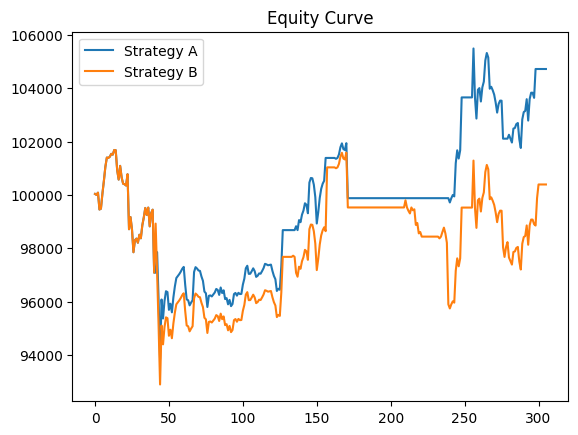

In [14]:
import matplotlib.pyplot as plt

plt.plot(equity_A, label="Strategy A")
plt.plot(equity_B, label="Strategy B")

plt.legend()
plt.title("Equity Curve")
plt.show()

In [15]:
import optuna
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

# ======================
# 指標関数
# ======================
def calc_metrics(equity):

    equity = np.array(equity)

    if len(equity) < 2:
        return {"Sharpe": 0.0, "PF": 0.0, "Max DD": 1.0}

    returns = np.diff(equity) / (equity[:-1] + 1e-9)

    gains = returns[returns > 0].sum()
    losses = -returns[returns < 0].sum()
    pf = gains / (losses + 1e-9)

    expectancy = returns.mean()

    peak = np.maximum.accumulate(equity)
    dd = (equity - peak) / (peak + 1e-9)
    max_dd = abs(dd.min())

    vol = returns.std() + 1e-9
    sharpe = expectancy / vol * np.sqrt(252)

    return {
        "Sharpe": sharpe,
        "PF": pf,
        "Max DD": max_dd
    }


# ======================
# Optuna Objective（完成版）
# ======================
def objective(trial):

    # ===== モデル =====
    model_params = {
        'n_estimators': trial.suggest_int('n_estimators', 80, 250),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.15),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 0.4),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 0.5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 2.0)
    }

    # ===== 戦略 =====
    w_trend = trial.suggest_float('w_trend', 0.0, 3.0)
    w_vol = trial.suggest_float('w_vol', 0.0, 3.0)
    w_mom = trial.suggest_float('w_mom', 0.0, 5.0)

    entry_q = trial.suggest_float('entry_q', 0.6, 0.85)
    adx_th = trial.suggest_float('adx_th', 10, 25)
    use_slope = trial.suggest_categorical('use_slope', [True, False])

    tscv = TimeSeriesSplit(n_splits=5)

    sharpe_list = []
    trade_list = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # ===== SMOTE =====
        smote = SMOTE(random_state=42)
        X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

        # ===== スケーリング（重要：trainでfit）=====
        scaler = StandardScaler()
        X_train_res = scaler.fit_transform(X_train_res)
        X_test_scaled = scaler.transform(X_test)

        # ===== モデル =====
        model = XGBClassifier(
            **model_params,
            random_state=42,
            eval_metric='logloss',
            n_jobs=-1
        )

        model.fit(X_train_res, y_train_res)

        proba = model.predict_proba(X_test_scaled)[:, 1]

        # ===== df =====
        df_slice = df.loc[X_test.index].copy()
        df_slice["proba"] = proba
        df_slice["TREND_STRENGTH"] = df.loc[X_test.index, "TREND_STRENGTH"]
        df_slice["Volatility_Short"] = df.loc[X_test.index, "Volatility_Short"]
        df_slice["RET_5"] = df.loc[X_test.index, "RET_5"]
        df_slice["ADX"] = df.loc[X_test.index, "ADX"]

        # ===== スコア =====
        df_slice["score"] = (
            df_slice["proba"]
            + w_trend * df_slice["TREND_STRENGTH"].abs()
            - w_vol * df_slice["Volatility_Short"]
            + w_mom * df_slice["RET_5"]
        )

        # ====== 新しいシグナル生成ロジック ======

        # ② スコアを正規化してポジションサイズに反映
        score_norm = (df_slice["score"] - df_slice["score"].min()) / (
            df_slice["score"].max() - df_slice["score"].min() + 1e-9
        )

        # ③ トレンドフィルターをON/OFFから連続値に変更
        adx_ma = df_slice["ADX"].rolling(20, min_periods=1).mean()
        slope = df_slice["ADX"].diff().rolling(5, min_periods=1).mean() # スロープはuse_slopeで使用する可能性があるため計算

        trend_strength = (adx_ma - adx_th) / adx_th
        trend_strength = np.clip(trend_strength, 0, 1)

        if use_slope:
            # use_slopeがTrueの場合、スロープが0以下ならトレンド強度を0にする
            trend_strength = trend_strength * (slope > 0).astype(float)

        # ④ 最終シグナル
        # score_normは0-1、trend_strengthも0-1なので、signalsも0-1の範囲に
        signals = score_norm * trend_strength

        # ===== バックテスト =====
        results, equity, _ = run_backtest(df, X_test, signals)

        metrics = calc_metrics(equity)

        # ===== 早期終了（超重要）=====
        if metrics["Max DD"] > 0.08:
            raise optuna.exceptions.TrialPruned()

        sharpe_list.append(metrics["Sharpe"])
        trade_list.append(results["Total Trades"])

    # ===== トレード数制限 =====
    if np.mean(trade_list) < 6:
        return -1e6

    # ===== 最終スコア =====
    score = np.mean(sharpe_list) - 0.5 * np.std(sharpe_list)

    return score

In [16]:
import optuna
import json

# ======================
# 最適化実行
# ======================
study = optuna.create_study(direction='maximize')

study.optimize(objective, n_trials=100)

# ======================
# ベスト結果
# ======================
best_params = study.best_params

print("\n===== BEST RESULT =====")
print("Score:", study.best_value)
print("Params:")
for k, v in best_params.items():
    print(f"{k}: {v}")

# ======================
# 保存（超重要）
# ======================
with open("best_params.json", "w") as f:
    json.dump(best_params, f)

print("\n✅ best_params.json に保存完了")

# ======================
# 分解（モデル用と戦略用）
# ======================
model_params = {
    k: best_params[k]
    for k in [
        'n_estimators', 'max_depth', 'learning_rate',
        'subsample', 'colsample_bytree',
        'gamma', 'reg_alpha', 'reg_lambda'
    ]
}

strategy_params = {
    k: best_params[k]
    for k in [
        'w_trend', 'w_vol', 'w_mom',
        'entry_q', 'adx_th', 'use_slope'
    ]
}

print("\nModel Params:", model_params)
print("Strategy Params:", strategy_params)

[I 2026-04-25 19:04:17,581] A new study created in memory with name: no-name-2545bcc7-cdc9-476f-b1d9-7b3c5699f61b
[I 2026-04-25 19:04:20,832] Trial 0 finished with value: 0.06117972120517323 and parameters: {'n_estimators': 163, 'max_depth': 3, 'learning_rate': 0.0626214958485677, 'subsample': 0.7213626731561413, 'colsample_bytree': 0.8095798755196097, 'gamma': 0.24818132235146978, 'reg_alpha': 0.027628919197656143, 'reg_lambda': 1.9761478142030688, 'w_trend': 2.8034360753206458, 'w_vol': 1.6132760833421709, 'w_mom': 4.184292171469489, 'entry_q': 0.7736821490458774, 'adx_th': 14.301916768135584, 'use_slope': False}. Best is trial 0 with value: 0.06117972120517323.
[I 2026-04-25 19:04:23,022] Trial 1 finished with value: -0.21828188538041066 and parameters: {'n_estimators': 239, 'max_depth': 4, 'learning_rate': 0.06585094507987244, 'subsample': 0.863781517843379, 'colsample_bytree': 0.8526923328644855, 'gamma': 0.06945811857272154, 'reg_alpha': 0.22815526844745598, 'reg_lambda': 1.36017


===== BEST RESULT =====
Score: 0.6276073051533129
Params:
n_estimators: 99
max_depth: 7
learning_rate: 0.09688448949751548
subsample: 0.748005899831383
colsample_bytree: 0.6438090489699417
gamma: 0.3674822949934749
reg_alpha: 0.08671768291698301
reg_lambda: 1.6363924310917477
w_trend: 1.1347148488730725
w_vol: 0.9501355731580637
w_mom: 2.6116470419316293
entry_q: 0.7600938244103969
adx_th: 10.00625888327116
use_slope: True

✅ best_params.json に保存完了

Model Params: {'n_estimators': 99, 'max_depth': 7, 'learning_rate': 0.09688448949751548, 'subsample': 0.748005899831383, 'colsample_bytree': 0.6438090489699417, 'gamma': 0.3674822949934749, 'reg_alpha': 0.08671768291698301, 'reg_lambda': 1.6363924310917477}
Strategy Params: {'w_trend': 1.1347148488730725, 'w_vol': 0.9501355731580637, 'w_mom': 2.6116470419316293, 'entry_q': 0.7600938244103969, 'adx_th': 10.00625888327116, 'use_slope': True}


In [17]:
print("proba exists:", "proba" in globals())

proba exists: False


In [18]:
model = XGBClassifier(
    **model_params,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

In [20]:
# ======================
# 最終モデル + 最終バックテスト（完成版）
# ======================

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler # Added for feature scaling

# ======================
# パラメータ取得（-lj2XmmykqNY で抽出済みのものを使用）
# ======================

# model_params は -lj2XbSmf_r3a で定義済み
# 新しい戦略パラメータを strategy_params から取得

w_trend_strength = strategy_params.get("w_trend")
w_volatility_penalty = strategy_params.get("w_vol")
w_momentum = strategy_params.get("w_mom")
entry_q = strategy_params.get("entry_q")
adx_th = strategy_params.get("adx_th")
use_slope = strategy_params.get("use_slope")

print("Final Model Params:", model_params)
print("Final Entry Ranking Model Weights: Trend Strength=", w_trend_strength, ", Volatility Penalty=", w_volatility_penalty, ", Momentum=", w_momentum)
print("Final Entry Filter Params: Entry Quantile=", entry_q, ", ADX Threshold=", adx_th, ", Use Slope=", use_slope)

# ======================
# 再学習
# ======================

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

final_model = XGBClassifier(
    **model_params,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

final_model.fit(X_train_resampled.values, y_train_resampled.values)

# ======================
# 予測
# ======================

# Predict probabilities for both original training and test sets
proba_final_train = final_model.predict_proba(X_train.values)[:, 1] # Predict on original X_train
proba_final_test = final_model.predict_proba(X_test.values)[:, 1]

# ======================
# 戦略生成（Simple Threshold Entry with Trend Filter and Consecutive Entry Prevention）
# ======================

# Prepare df_train_for_scaling (original training data + predicted proba and other features)
df_train_for_scaling = df.loc[X_train.index].copy()
df_train_for_scaling["proba"] = proba_final_train
# Ensure other features for scaling are also in df_train_for_scaling
df_train_for_scaling['TREND_STRENGTH'] = df.loc[X_train.index, 'TREND_STRENGTH']
df_train_for_scaling['Volatility_Short'] = df.loc[X_train.index, 'Volatility_Short']
df_train_for_scaling['RET_5'] = df.loc[X_train.index, 'RET_5']


df_test_slice = df.loc[X_test.index].copy()
df_test_slice["proba"] = proba_final_test

# Ensure all required features for Entry Ranking Model are in df_test_slice
df_test_slice['ADX'] = df.loc[X_test.index, 'ADX']
df_test_slice['Volatility_Short'] = df.loc[X_test.index, 'Volatility_Short']
df_test_slice['TREND_STRENGTH'] = df.loc[X_test.index, 'TREND_STRENGTH']
df_test_slice['RET_5'] = df.loc[X_test.index, 'RET_5']

# === Feature Scaling for Final Backtest (Issue ④) ===
scaler_final = StandardScaler()
cols_to_scale_final = ["proba", "TREND_STRENGTH", "Volatility_Short", "RET_5"]

# Fit scaler on df_train_for_scaling for the specified columns
scaler_final.fit(df_train_for_scaling[cols_to_scale_final])

# Transform df_test_slice for the specified columns using the fitted scaler
df_test_slice[cols_to_scale_final] = scaler_final.transform(df_test_slice[cols_to_scale_final])

# Calculate Entry Score based on optimized weights
df_test_slice["entry_score"] = (
    df_test_slice["proba"]
    + w_trend_strength * df_test_slice["TREND_STRENGTH"].abs()
    - w_volatility_penalty * df_test_slice["Volatility_Short"]
    + w_momentum * df_test_slice["RET_5"]
)

# --- New Trend Filter Calculation ---
adx_rolling_mean = df_test_slice["ADX"].rolling(20, min_periods=1).mean()
adx_slope = df_test_slice["ADX"].diff()
adx_slope_mean = adx_slope.rolling(5, min_periods=1).mean()

# Apply optimized ADX filter logic
if use_slope:
    trend_filter = (adx_rolling_mean > adx_th) & (adx_slope_mean > 0)
else:
    trend_filter = (adx_rolling_mean > adx_th)

# Apply new signal generation: entry_score > dynamic_threshold AND trend_filter
signals_final = (
    (df_test_slice["entry_score"] > df_test_slice["entry_score"].quantile(entry_q)) &
    trend_filter
).astype(float)

# Removed consecutive signal suppression (③ - test by completely removing)
# signals_final = signals_final * (signals_final.shift(1).fillna(0) == 0).astype(float)

signals_final = pd.Series(signals_final, index=X_test.index)

# ======================
# バックテスト
# ======================

results_final, equity_final, trade_pnls_final = run_backtest(
    df,
    X_test,
    signals_final
)

# ======================
# 結果
# ======================

print("===== FINAL RESULT ====")
for k, v in results_final.items():
    print(f"{k}: {v}")

Final Model Params: {'n_estimators': 99, 'max_depth': 7, 'learning_rate': 0.09688448949751548, 'subsample': 0.748005899831383, 'colsample_bytree': 0.6438090489699417, 'gamma': 0.3674822949934749, 'reg_alpha': 0.08671768291698301, 'reg_lambda': 1.6363924310917477}
Final Entry Ranking Model Weights: Trend Strength= 1.1347148488730725 , Volatility Penalty= 0.9501355731580637 , Momentum= 2.6116470419316293
Final Entry Filter Params: Entry Quantile= 0.7600938244103969 , ADX Threshold= 10.00625888327116 , Use Slope= True
===== FINAL RESULT ====
Final Balance: 96820.61779696243
Total Return (%): -3.179382203037573
Total Trades: 7
Win Rate (%): 28.57142857142857
PF: 0.8389196539366436
Expectancy: -0.00010111315941858642
Max DD: -0.06012572935597347
Sharpe: -0.5190002661284628


In [22]:
# ======================
# トレードP/L分析
# ======================

if trade_pnls_final:
    winning_trades = [pnl for pnl in trade_pnls_final if pnl > 0]
    losing_trades = [pnl for pnl in trade_pnls_final if pnl < 0]

    avg_win = np.mean(winning_trades) if winning_trades else 0
    avg_loss = np.mean(losing_trades) if losing_trades else 0

    print(f"平均勝ちトレード金額: {avg_win:.2f}")
    print(f"平均負けトレード金額: {avg_loss:.2f}")
    print(f"リスクリワード比 (Avg Win / |Avg Loss|): {abs(avg_win / avg_loss):.2f}" if avg_loss != 0 else "リスクリワード比: N/A (負けトレードなし)")
else:
    print("トレード履歴がありません。")


平均勝ちトレード金額: 2182.67
平均負けトレード金額: -1508.94
リスクリワード比 (Avg Win / |Avg Loss|): 1.45


In [23]:
# ======================
# signalsの連打チェック
# ======================

# signals_finalのインデックスがDatetimeIndexであることを確認
if isinstance(signals_final.index, pd.DatetimeIndex):
    # 日付ごとにグループ化し、シグナルが1であるものの数をカウント
    # フィルタリングされたSeriesのインデックスを直接使うことで、Grouperとaxisの長さの不一致を解消
    filtered_signals = signals_final[signals_final == 1]
    daily_signals_count = filtered_signals.groupby(filtered_signals.index.date).count()

    # 1日に複数のシグナルが発生している日を抽出
    multiple_signals_days = daily_signals_count[daily_signals_count > 1]

    if not multiple_signals_days.empty:
        print("1日に複数のシグナルが発生している日があります:")
        print(multiple_signals_days)

        # 具体的なシグナルを表示するために、該当日のデータをフィルタリング
        for date_obj in multiple_signals_days.index:
            date = pd.Timestamp(date_obj)
            print(f"\n--- {date.date()} のシグナル ---")
            # ここでもfiltered_signalsから該当日のデータを取得するように修正
            print(filtered_signals.loc[date.date()])
    else:
        print("1日に複数のシグナルが発生している日はありません。")
else:
    print("signals_finalのインデックスがDatetimeIndexではありません。")


1日に複数のシグナルが発生している日はありません。


### `signals_final` のポジションサイズ分布の確認
`signals_final` の値が極端に小さい、または大きくなる可能性があるというご指摘を受け、その分布を確認します。これにより、トレードのポジションサイズが適切に調整されているか、または問題のある値が存在しないかを評価します。

signals_finalの記述統計量:
count    307.000000
mean       0.100977
std        0.301790
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
dtype: float64


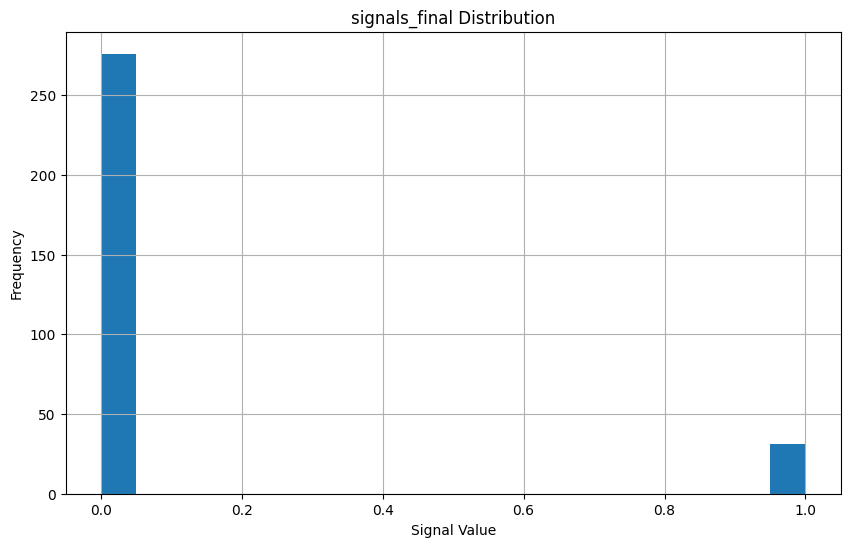

In [24]:
# ======================
# signals_finalの分布確認
# ======================

print("signals_finalの記述統計量:")
print(signals_final.describe())

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
signals_final.hist(bins=20)
plt.title('signals_final Distribution')
plt.xlabel('Signal Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


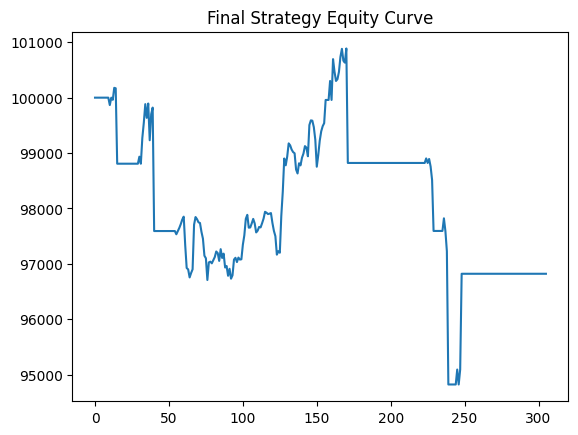

In [25]:
import matplotlib.pyplot as plt

plt.plot(equity_final)
plt.title("Final Strategy Equity Curve")
plt.show()

### `signals_final` とボラティリティの関係性の確認

`signals_final` のポジションサイズが低ボラティリティ環境で大きくなりすぎていないか確認するため、最終シグナル値とボラティリティ（`Volatility_Short`）の関係を散布図で可視化します。

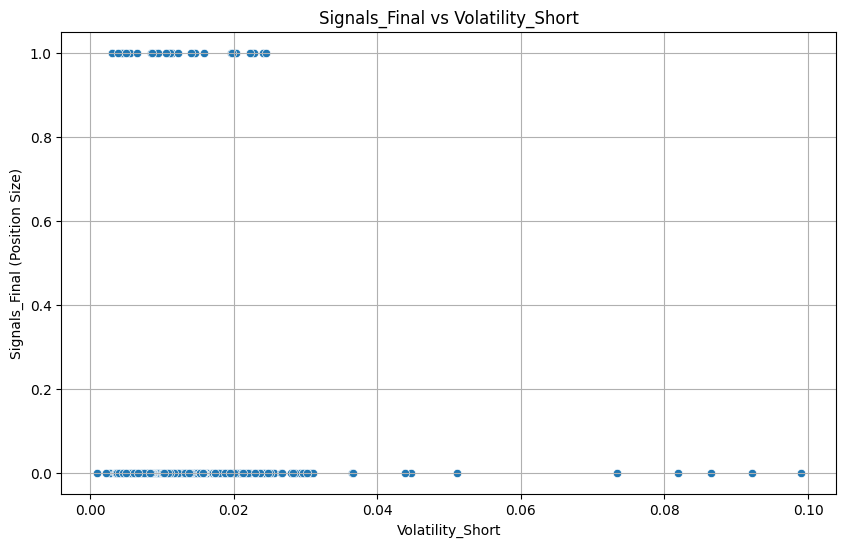

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# df_test_sliceはh_uXbSmf_r3aセルで定義されたものです。
# signals_finalはX_testのインデックスにアライメントされています。

# X_testの期間に対応するVolatility_Shortを取得
volatility_short_for_signals = df.loc[X_test.index, 'Volatility_Short']

# signals_finalとVolatility_Shortを結合してDataFrameを作成
plot_df = pd.DataFrame({
    'Signals_Final': signals_final,
    'Volatility_Short': volatility_short_for_signals
})

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Volatility_Short', y='Signals_Final', data=plot_df)
plt.title('Signals_Final vs Volatility_Short')
plt.xlabel('Volatility_Short')
plt.ylabel('Signals_Final (Position Size)')
plt.grid(True)
plt.show()


In [27]:
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

results_list = []
equity_curves = []

best_params_cv = study.best_params.copy()


# ======================
# 指標関数 (Updated to include Sharpe Ratio explicitly)
# ======================

def calc_metrics(equity):
    equity = np.array(equity)

    if len(equity) < 2:
        return { "PF": 0.0, "Expectancy": 0.0, "Max DD": 0.0, "Sharpe": 0.0, "Sortino": 0.0, "Stability": 0.0 }

    returns = np.diff(equity) / equity[:-1]

    # PF
    gains = returns[returns > 0].sum()
    losses = -returns[returns < 0].sum()
    pf = gains / (losses + 1e-9)

    # Expectancy
    expectancy = returns.mean()

    # Max DD
    peak = np.maximum.accumulate(equity)
    dd = (equity - peak) / peak
    max_dd = dd.min()

    # Stability (inverse of volatility)
    vol = returns.std() + 1e-9
    stability = 1 / vol

    # Sharpe
    sharpe = expectancy / vol * np.sqrt(252)

    # Sortino (assuming risk-free rate is 0)
    downside = returns[returns < 0]

    if len(downside) < 3:
        sortino = 0.0   # Set to 0 if not enough data for downside deviation
    else:
        sortino = np.mean(returns) / (np.std(downside) + 1e-9)

    return {
        "PF": pf,
        "Expectancy": expectancy,
        "Max DD": max_dd,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Stability": stability
    }


# ======================
# CV
# ======================

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):

    print(f"\n===== Fold {fold+1} ====")

    X_train_cv, X_test_cv = X.iloc[train_idx], X.iloc[test_idx]
    y_train_cv, y_test_cv = y.iloc[train_idx], y.iloc[test_idx]

    # Print the time range for the test set of the current fold
    print(f"Test period: {X_test_cv.index.min()} to {X_test_cv.index.max()}")

    # SMOTE
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train_cv, y_train_cv)

    # model params
    # XGBoostモデルに渡すパラメータのみを抽出
    model_params_for_xgb = {
        k: best_params_cv[k]
        for k in best_params_cv
        if k in ['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree', 'gamma', 'reg_alpha', 'reg_lambda']
    }

    model = XGBClassifier(
        **model_params_for_xgb,
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    )

    model.fit(X_train_res.values, y_train_res.values)

    # prediction
    proba = model.predict_proba(X_test_cv.values)[:, 1]

    # align df
    df_slice = df.loc[X_test_cv.index].copy()
    df_slice["proba"] = proba

    # Re-calculate required features for signal generation
    df_slice['ADX'] = df.loc[X_test_cv.index, 'ADX']
    df_slice['Volatility_Short'] = df.loc[X_test_cv.index, 'Volatility_Short']
    df_slice['TREND_STRENGTH'] = df.loc[X_test_cv.index, 'TREND_STRENGTH']
    df_slice['RET_5'] = df.loc[X_test_cv.index, 'RET_5'] # Add RET_5 for the new Entry Ranking Model

    # Retrieve Entry Ranking Model weights and new filter parameters
    # Corrected key names
    w_trend_strength_cv = best_params_cv.get("w_trend")
    w_volatility_penalty_cv = best_params_cv.get("w_vol")
    w_momentum_cv = best_params_cv.get("w_mom")
    entry_q_cv = best_params_cv.get("entry_q")
    adx_th_cv = best_params_cv.get("adx_th")
    use_slope_cv = best_params_cv.get("use_slope")

    # Calculate Entry Score based on optimized weights
    df_slice["entry_score"] = (
        df_slice["proba"]
        + w_trend_strength_cv * df_slice["TREND_STRENGTH"].abs()
        - w_volatility_penalty_cv * df_slice["Volatility_Short"]
        + w_momentum_cv * df_slice["RET_5"]
    )

    # --- New Trend Filter Calculation ---
    adx_rolling_mean = df_slice["ADX"].rolling(20, min_periods=1).mean()
    adx_slope = df_slice["ADX"].diff()
    adx_slope_mean = adx_slope.rolling(5, min_periods=1).mean()

    # Apply optimized ADX filter logic
    if use_slope_cv:
        trend_filter = (adx_rolling_mean > adx_th_cv) & (adx_slope_mean > 0)
    else:
        trend_filter = (adx_rolling_mean > adx_th_cv)

    # Debugging logs as per point ④
    df_debug_cv = df_slice.copy()
    df_debug_cv["cond_score"] = df_debug_cv["entry_score"] > df_debug_cv["entry_score"].quantile(entry_q_cv)
    df_debug_cv["cond_trend"] = trend_filter
    df_debug_cv["cond_final"] = df_debug_cv["cond_score"] & df_debug_cv["cond_trend"]

    print(f"Fold {fold+1} - score通過率:", df_debug_cv["cond_score"].mean())
    print(f"Fold {fold+1} - trend通過率:", df_debug_cv["cond_trend"].mean())
    print(f"Fold {fold+1} - 最終通過率:", df_debug_cv["cond_final"].mean())

    # Apply new signal generation: entry_score > dynamic_threshold AND trend_filter
    signals_series = pd.Series(0.0, index=df_slice.index)
    if not df_slice.empty:
        signals_series = (
            (df_slice["entry_score"] > df_slice["entry_score"].quantile(entry_q_cv)) &
            trend_filter
        ).astype(float)

        # Removed consecutive signal suppression (③ - test by completely removing)
        # signals_series = signals_series * (signals_series.shift(1).fillna(0) == 0).astype(float)


    # backtest
    results, equity, _ = run_backtest(
        df,
        X_test_cv,
        signals_series
    )

    # ======================
    # 追加：全部の指標
    # ======================
    metrics = calc_metrics(equity)
    results.update(metrics)

    results_list.append(results)
    equity_curves.append(equity)

    print(results)


# ======================
# summary
# ======================

df_results = pd.DataFrame(results_list)

print("\n===== CV SUMMARY ====")
print(df_results.mean())

print("\nSTD:")
print(df_results.std())


===== Fold 1 ====
Test period: 2021-03-29 00:00:00 to 2022-03-30 00:00:00
Fold 1 - score通過率: 0.23921568627450981
Fold 1 - trend通過率: 0.4823529411764706
Fold 1 - 最終通過率: 0.13725490196078433
{'Final Balance': np.float64(106784.06432157215), 'Total Return (%)': np.float64(6.7840643215721474), 'Total Trades': 11, 'Win Rate (%)': 54.54545454545454, 'PF': np.float64(1.2691856132809145), 'Expectancy': np.float64(0.00026971165792176785), 'Max DD': np.float64(-0.03225509728911628), 'Sharpe': np.float64(0.9443086507626787), 'Sortino': np.float64(0.0725977070881453), 'Stability': np.float64(220.55351277344272)}

===== Fold 2 ====
Test period: 2022-03-31 00:00:00 to 2023-04-05 00:00:00
Fold 2 - score通過率: 0.23921568627450981
Fold 2 - trend通過率: 0.5098039215686274
Fold 2 - 最終通過率: 0.12156862745098039
{'Final Balance': np.float64(99199.5044900146), 'Total Return (%)': np.float64(-0.8004955099853994), 'Total Trades': 8, 'Win Rate (%)': 37.5, 'PF': np.float64(0.966950008483684), 'Expectancy': np.float64(-

In [28]:
X.index.equals(df.index)

True

In [30]:
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

results_list = []
equity_curves = []

best_params_cv = study.best_params.copy()


# ======================
# 指標関数 (Updated to include Sharpe Ratio explicitly)
# ======================

def calc_metrics(equity):
    equity = np.array(equity)

    if len(equity) < 2:
        return { "PF": 0.0, "Expectancy": 0.0, "Max DD": 0.0, "Sharpe": 0.0, "Sortino": 0.0, "Stability": 0.0 }

    returns = np.diff(equity) / equity[:-1]

    # PF
    gains = returns[returns > 0].sum()
    losses = -returns[returns < 0].sum()
    pf = gains / (losses + 1e-9)

    # Expectancy
    expectancy = returns.mean()

    # Max DD
    peak = np.maximum.accumulate(equity)
    dd = (equity - peak) / peak
    max_dd = dd.min()

    # Stability (inverse of volatility)
    vol = returns.std() + 1e-9
    stability = 1 / vol

    # Sharpe
    sharpe = expectancy / vol * np.sqrt(252)

    # Sortino (assuming risk-free rate is 0)
    downside = returns[returns < 0]

    if len(downside) < 3:
        sortino = 0.0   # Set to 0 if not enough data for downside deviation
    else:
        sortino = np.mean(returns) / (np.std(downside) + 1e-9)

    return {
        "PF": pf,
        "Expectancy": expectancy,
        "Max DD": max_dd,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Stability": stability
    }


# ======================
# CV
# ======================

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):

    print(f"\n===== Fold {fold+1} ====")

    X_train_cv, X_test_cv = X.iloc[train_idx], X.iloc[test_idx]
    y_train_cv, y_test_cv = y.iloc[train_idx], y.iloc[test_idx]

    # Print the time range for the test set of the current fold
    print(f"Test period: {X_test_cv.index.min()} to {X_test_cv.index.max()}")

    # SMOTE
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train_cv, y_train_cv)

    # model params
    # XGBoostモデルに渡すパラメータのみを抽出
    model_params_for_xgb = {
        k: best_params_cv[k]
        for k in best_params_cv
        if k in ['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree', 'gamma', 'reg_alpha', 'reg_lambda']
    }

    model = XGBClassifier(
        **model_params_for_xgb,
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    )

    model.fit(X_train_res.values, y_train_res.values)

    # prediction
    proba = model.predict_proba(X_test_cv.values)[:, 1]

    # align df
    df_slice = df.loc[X_test_cv.index].copy()
    df_slice["proba"] = proba

    # Re-calculate required features for signal generation
    df_slice['ADX'] = df.loc[X_test_cv.index, 'ADX']
    df_slice['Volatility_Short'] = df.loc[X_test_cv.index, 'Volatility_Short']
    df_slice['TREND_STRENGTH'] = df.loc[X_test_cv.index, 'TREND_STRENGTH']
    df_slice['RET_5'] = df.loc[X_test_cv.index, 'RET_5'] # Add RET_5 for the new Entry Ranking Model

    # Retrieve Entry Ranking Model weights and new filter parameters
    w_trend_strength_cv = best_params_cv.get("w_trend")
    w_volatility_penalty_cv = best_params_cv.get("w_vol")
    w_momentum_cv = best_params_cv.get("w_mom")
    entry_q_cv = best_params_cv.get("entry_q")
    adx_th_cv = best_params_cv.get("adx_th")
    use_slope_cv = best_params_cv.get("use_slope")

    # Calculate Entry Score based on optimized weights
    df_slice["entry_score"] = (
        df_slice["proba"]
        + w_trend_strength_cv * df_slice["TREND_STRENGTH"].abs()
        - w_volatility_penalty_cv * df_slice["Volatility_Short"]
        + w_momentum_cv * df_slice["RET_5"]
    )

    # --- New Trend Filter Calculation ---
    adx_rolling_mean = df_slice["ADX"].rolling(20, min_periods=1).mean()
    adx_slope = df_slice["ADX"].diff()
    adx_slope_mean = adx_slope.rolling(5, min_periods=1).mean()

    # Apply optimized ADX filter logic
    if use_slope_cv:
        trend_filter = (adx_rolling_mean > adx_th_cv) & (adx_slope_mean > 0)
    else:
        trend_filter = (adx_rolling_mean > adx_th_cv)

    # Debugging logs as per point ④
    df_debug_cv = df_slice.copy()
    df_debug_cv["cond_score"] = df_debug_cv["entry_score"] > df_debug_cv["entry_score"].quantile(entry_q_cv)
    df_debug_cv["cond_trend"] = trend_filter
    df_debug_cv["cond_final"] = df_debug_cv["cond_score"] & df_debug_cv["cond_trend"]

    print(f"Fold {fold+1} - score通過率:", df_debug_cv["cond_score"].mean())
    print(f"Fold {fold+1} - trend通過率:", df_debug_cv["cond_trend"].mean())
    print(f"Fold {fold+1} - 最終通過率:", df_debug_cv["cond_final"].mean())

    # Apply new signal generation: entry_score > dynamic_threshold AND trend_filter
    signals_series = pd.Series(0.0, index=df_slice.index)
    if not df_slice.empty:
        signals_series = (
            (df_slice["entry_score"] > df_slice["entry_score"].quantile(entry_q_cv)) &
            trend_filter
        ).astype(float)

        # Removed consecutive signal suppression (③ - test by completely removing)
        # signals_series = signals_series * (signals_series.shift(1).fillna(0) == 0).astype(float)


    # backtest
    results, equity, _ = run_backtest(
        df,
        X_test_cv,
        signals_series
    )

    # ======================
    # 追加：全部の指標
    # ======================
    metrics = calc_metrics(equity)
    results.update(metrics)

    results_list.append(results)
    equity_curves.append(equity)

    print(results)


# ======================
# summary
# ======================

df_results = pd.DataFrame(results_list)

print("\n===== CV SUMMARY ====")
print(df_results.mean())

print("\nSTD:")
print(df_results.std())


===== Fold 1 ====
Test period: 2021-03-29 00:00:00 to 2022-03-30 00:00:00
Fold 1 - score通過率: 0.23921568627450981
Fold 1 - trend通過率: 0.4823529411764706
Fold 1 - 最終通過率: 0.13725490196078433
{'Final Balance': np.float64(106784.06432157215), 'Total Return (%)': np.float64(6.7840643215721474), 'Total Trades': 11, 'Win Rate (%)': 54.54545454545454, 'PF': np.float64(1.2691856132809145), 'Expectancy': np.float64(0.00026971165792176785), 'Max DD': np.float64(-0.03225509728911628), 'Sharpe': np.float64(0.9443086507626787), 'Sortino': np.float64(0.0725977070881453), 'Stability': np.float64(220.55351277344272)}

===== Fold 2 ====
Test period: 2022-03-31 00:00:00 to 2023-04-05 00:00:00
Fold 2 - score通過率: 0.23921568627450981
Fold 2 - trend通過率: 0.5098039215686274
Fold 2 - 最終通過率: 0.12156862745098039
{'Final Balance': np.float64(99199.5044900146), 'Total Return (%)': np.float64(-0.8004955099853994), 'Total Trades': 8, 'Win Rate (%)': 37.5, 'PF': np.float64(0.966950008483684), 'Expectancy': np.float64(-

In [ ]:
print('ADX' in df.columns)
print(df.columns)

In [ ]:
df_debug = df_slice.copy()

# 条件ごとにTrue/Falseを記録
df_debug["cond_proba"] = df_debug["proba"] > df_debug["proba"].quantile(0.9)
df_debug["cond_trend"] = trend_filter
df_debug["cond_final"] = (df_debug["cond_proba"] & df_debug["cond_trend"])

# 通過率確認
print("proba通過率:", df_debug["cond_proba"].mean())
print("trend通過率:", df_debug["cond_trend"].mean())
print("最終通過率:", df_debug["cond_final"].mean())